# Paper experiments — Our model vs BCO / NBCO / classical baselines

**Framing.** Previously a transit network was generated *from scratch* and
refined by BCO. In practice you cannot regenerate / heavily change a deployed
network. So we (a) keep changes small (measure **adjustment degree `adj`** vs
the seed), (b) replace heuristic type-2 mutations with **smart trim/extend**
edits for precise control, and (c) move from ATT toward **RTT + connectivity**
(+ adj). The thesis: Our model matches RTT, improves connectivity, removes
duplicates, and deviates little from the seed (low adj).

This notebook is a **skeleton**: the edit-model checkpoint is a single swappable
knob (`OUR_MODEL_PATH`), and `SMOKE=True` runs a fast 1-city sanity pass.

In [1]:
import os, sys
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "1")
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import display

from eval_lib.context import ROOT_DIR, EDIT_MODEL_WEIGHTS_DIR
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
from eval_lib import *                      # runners, builders, BENCHMARK_SPECS, ...
from eval_lib import _run_baseline          # private: not pulled by `import *`
from eval_lib import plots as route_plots
from connectpt.routes_generator.bee_colony import get_adjustment_degrees

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pd.set_option("display.max_columns", None)
print("device:", device)

device: cpu


## Configuration

`SMOKE=True` -> Mandl only, 1 seed, tiny iteration budgets (just checks the
pipeline builds tables/figures). Flip to `False` for the full Mumford0-3 run.

In [2]:
SMOKE = True
QUICK = False   # minimal budgets/sweeps just to verify the notebook runs end-to-end
CITIES = ["Mandl"] if SMOKE else ["Mandl", "Mumford0", "Mumford1", "Mumford2", "Mumford3"]
SEEDS = [0]

# Baselines optimize ATT+RTT at alpha=0.5 (connectivity off), as in prior work.
BASE_WEIGHTS = dict(demand_time_weight=0.5, route_time_weight=0.5,
                    median_connectivity_weight=0.0)
# Our model is NBCO with neural rebuild bees + our trim/extend bees
# replacing the type-2 local endpoint edits. It optimizes RTT + connectivity
# (demand off); adj is measured.
OUR_WEIGHTS = dict(demand_time_weight=0.0, route_time_weight=0.5,
                   median_connectivity_weight=0.5)

# >>> SWAPPABLE MODEL SLOT: point at any trim-model checkpoint <<<
# (later: a route+conn+adj model trained in the lc_redundancy notebook)
_cands = [
    EDIT_MODEL_WEIGHTS_DIR / "improvement_lc_copy_subcopy_curriculum_route_conn_no_adj_resume.pt",
    EDIT_MODEL_WEIGHTS_DIR / "improvement_lc_copy_subcopy_curriculum_route_conn_no_adj.pt",
]
OUR_MODEL_PATH = next((p for p in _cands if p.exists()), _cands[-1])

# BCO edit/trim bees also load the edit model via eval_lib's default
# path. Point it at the same new 18-dim (redundancy) checkpoint so it
# matches the bestsofar_feb2023_trim architecture.
import eval_lib.helpers as _eh
_eh.EDIT_MODEL_WEIGHTS_PATH = OUR_MODEL_PATH
if QUICK:
    _eh.BCO_N_ITERATIONS = 5   # tiny BCO budget for run_method sweeps (E5)

ADJ_GAP, ADJ_MODE = 0.1, "paper"
ADJ_FIXED_W = 2.0   # fixed adj penalty weight; the E2 sweep varies the TARGET instead

# Early stopping OFF: every method runs its full iteration budget so the
# convergence curves below are complete (no premature termination).
EARLY_STOP_PATIENCE = None

# Base budgets. Mandl gets a separate tuned profile below because the first
# smoke convergence plot showed SA still wandering and GA/BCO stopping too soon.
DEFAULT_ALGO_SETTINGS = (
    dict(sa=200, hh=200, ga=20, ga_pop=10, nsgaii=(30, 20),
         bco=20, bco_bees=BCO_N_BEES, sa_args={}, bco_args={})
    if SMOKE else
    dict(sa=20000, hh=20000, ga=200, ga_pop=20, nsgaii=(1000, 200),
         bco=100, bco_bees=BCO_N_BEES, sa_args={}, bco_args={})
)

MANDL_ALGO_SETTINGS = dict(
    sa=(1200 if SMOKE else 20000),
    hh=(1200 if SMOKE else 20000),
    ga=(80 if SMOKE else 300),
    ga_pop=(40 if SMOKE else 60),
    nsgaii=((80, 40) if SMOKE else (1000, 200)),
    bco=(120 if SMOKE else 300),
    bco_bees=24,
    sa_args=dict(initial_temp=0.08, final_temp=0.003, cooling_rate=6.5e-5,
                 reheating_threshold=300, reheating_factor=1.02),
    bco_args=dict(worse_accept_temperature=0.02, worse_accept_decay=0.985,
                  worse_accept_min_temperature=0.001,
                  worse_selection_temperature=0.02,
                  worse_selection_decay=0.985,
                  worse_selection_uniform_mix=0.10,
                  worse_selection_elite_count=2),
)


def algo_settings(city):
    settings = dict(DEFAULT_ALGO_SETTINGS)
    if city == "Mandl":
        settings.update(MANDL_ALGO_SETTINGS)
    settings["sa_args"] = dict(DEFAULT_ALGO_SETTINGS.get("sa_args", {}),
                               **settings.get("sa_args", {}))
    settings["bco_args"] = dict(DEFAULT_ALGO_SETTINGS.get("bco_args", {}),
                                **settings.get("bco_args", {}))
    if QUICK:
        settings.update(sa=40, hh=40, ga=5, ga_pop=6, nsgaii=(10, 8),
                        bco=5, bco_bees=6)
    return settings

print("cities:", CITIES)
print("our model:", OUR_MODEL_PATH.name, "| exists:", OUR_MODEL_PATH.exists())
print("baseline weights (alpha=0.5):", BASE_WEIGHTS)
print("our weights (RTT+conn):", OUR_WEIGHTS)
print("algorithm settings:", {city: algo_settings(city) for city in CITIES})

# --- fixed coefficient grids for the Pareto fronts (same in QUICK/SMOKE/full) ---
ALPHA_GRID = [0.0, 0.25, 0.5, 0.75, 1.0]          # ATT/RTT (Cp/Co) sweep
ADJ_TARGET_GRID = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]  # adjustment-degree target sweep
E3_TARGETS = [0.0, 0.15, 0.3, 0.5]                # E3 route figures, per adj target
# OUR MODEL = "GNN + trim/extend" = neural-construction NBCO (GNN rebuild bee,
# type-1 + use_neural_bees) PLUS our trained trim/extend edit bee (type-5).
OUR_MODEL_LABEL = "GNN + trim/extend"
print("ALPHA_GRID", ALPHA_GRID, "| ADJ_TARGET_GRID", ADJ_TARGET_GRID,
      "| our model =", OUR_MODEL_LABEL)

cities: ['Mandl']
our model: improvement_lc_copy_subcopy_curriculum_route_conn_no_adj.pt | exists: True
baseline weights (alpha=0.5): {'demand_time_weight': 0.5, 'route_time_weight': 0.5, 'median_connectivity_weight': 0.0}
our weights (RTT+conn): {'demand_time_weight': 0.0, 'route_time_weight': 0.5, 'median_connectivity_weight': 0.5}
algorithm settings: {'Mandl': {'sa': 1200, 'hh': 1200, 'ga': 80, 'ga_pop': 40, 'nsgaii': (80, 40), 'bco': 120, 'bco_bees': 24, 'sa_args': {'initial_temp': 0.08, 'final_temp': 0.003, 'cooling_rate': 6.5e-05, 'reheating_threshold': 300, 'reheating_factor': 1.02}, 'bco_args': {'worse_accept_temperature': 0.02, 'worse_accept_decay': 0.985, 'worse_accept_min_temperature': 0.001, 'worse_selection_temperature': 0.02, 'worse_selection_decay': 0.985, 'worse_selection_uniform_mix': 0.1, 'worse_selection_elite_count': 2}}}
ALPHA_GRID [0.0, 0.25, 0.5, 0.75, 1.0] | ADJ_TARGET_GRID [0.0, 0.1, 0.2, 0.3, 0.4, 0.5] | our model = GNN + trim/extend


## Shared metrics: adjustment-degree vs seed + redundancy

In [3]:
from omegaconf import OmegaConf


def bco_cfg_set(cfg, **kv):
    """Set fields BCO reads from cfg (n_iterations, adjustment_degree_*)."""
    OmegaConf.set_struct(cfg, False)
    for k, v in kv.items():
        cfg[k] = v
    return cfg


def _set_cfg_value(cfg, dotted_key, value):
    """Set a nested OmegaConf value even when the composed cfg is structured."""
    target = cfg
    parts = dotted_key.split(".")
    for part in parts[:-1]:
        OmegaConf.set_struct(target, False)
        target = target[part]
    OmegaConf.set_struct(target, False)
    target[parts[-1]] = value
    return cfg


def _sa_cfg(city, run_name, n_routes, min_route_len, max_route_len):
    s = algo_settings(city)
    cfg = build_sa_cfg(run_name, n_routes, min_route_len, max_route_len,
                       n_iterations=s["sa"], early_stop_patience=EARLY_STOP_PATIENCE)
    for key, value in s.get("sa_args", {}).items():
        _set_cfg_value(cfg, f"alg_args.{key}", value)
    return cfg


def _ga_cfg(city, run_name, n_routes, min_route_len, max_route_len):
    s = algo_settings(city)
    return build_ga_cfg(run_name, n_routes, min_route_len, max_route_len,
                        n_iterations=s["ga"], population_size=s["ga_pop"],
                        early_stop_patience=EARLY_STOP_PATIENCE)


def _hh_cfg(city, run_name, n_routes, min_route_len, max_route_len):
    s = algo_settings(city)
    return build_hh_cfg(run_name, n_routes, min_route_len, max_route_len,
                        n_iterations=s["hh"], early_stop_patience=EARLY_STOP_PATIENCE)


def _variant_type1_bees(variant, n_bees):
    if variant.get("n_type2_bees") is None and variant.get("n_type1_bees") == BCO_N_TYPE1_BEES:
        return max(1, n_bees // 2)
    return variant["n_type1_bees"]


def _variant_bco_cfg(city, spec, variant, *, weights=BASE_WEIGHTS, run_name_suffix=""):
    s = algo_settings(city)
    n_bees = int(s["bco_bees"])
    cfg = build_bco_cfg(
        run_name=f"{city}_{run_name_suffix}{variant['run_name']}",
        n_routes=spec["n_routes"], min_route_len=spec["min_route_len"],
        max_route_len=spec["max_route_len"], use_neural_bees=variant["use_neural_bees"],
        n_bees=n_bees, n_type1_bees=_variant_type1_bees(variant, n_bees),
        n_type2_bees=variant["n_type2_bees"], n_type4_bees=variant["n_type4_bees"],
        n_type5_bees=variant.get("n_type5_bees", 0),
        n_type6_bees=variant.get("n_type6_bees", 0),
        n_type7_bees=variant.get("n_type7_bees", 0),
        **s.get("bco_args", {}), **weights)
    bco_cfg_set(cfg, n_iterations=s["bco"])
    return cfg


def _our_model_cfg(city, spec, *, adj_target=None, run_name_suffix=""):
    s = algo_settings(city)
    n_bees = int(s["bco_bees"])
    rebuild_bees = max(1, n_bees // 2)
    trim_extend_bees = n_bees - rebuild_bees
    cfg = build_bco_cfg(
        run_name=f"{city}_{run_name_suffix}our_nbco_neural_rebuild_trim_extend",
        n_routes=spec["n_routes"], min_route_len=spec["min_route_len"],
        max_route_len=spec["max_route_len"], use_neural_bees=True,
        n_bees=n_bees, n_type1_bees=rebuild_bees, n_type2_bees=0,
        n_type4_bees=0, n_type5_bees=trim_extend_bees,
        n_type6_bees=0, n_type7_bees=0,
        **s.get("bco_args", {}), **OUR_WEIGHTS)
    bco_cfg_set(cfg, n_iterations=s["bco"])
    if adj_target is not None:
        bco_cfg_set(cfg, adjustment_degree_weight=float(ADJ_FIXED_W),
                    adjustment_degree_objective="cap",
                    adjustment_degree_target=float(adj_target),
                    adjustment_degree_gap=ADJ_GAP, adjustment_degree_mode=ADJ_MODE)
    return cfg


def _run_our_model(city, spec, init, tensors, *, adj_target=None, run_name_suffix=""):
    cfg = _our_model_cfg(city, spec, adj_target=adj_target, run_name_suffix=run_name_suffix)
    return run_bco(cfg, init, tensors=tensors, run_name_scope=f"{city}_")


def adj_vs_init(routes, init_routes):
    r = as_route_tensor(routes); s = as_route_tensor(init_routes)
    if r.ndim == 2: r = r[None]
    if s.ndim == 2: s = s[None]
    nr = min(r.shape[1], s.shape[1]); w = min(r.shape[-1], s.shape[-1])
    return float(get_adjustment_degrees(
        r[:, :nr, :w], s[:, :nr, :w], True, gap=ADJ_GAP, mode=ADJ_MODE).mean().item())


def redundancy_pct(routes):
    R = as_route_tensor(routes)
    if R.ndim == 3: R = R[0]
    counts = Counter()
    for row in R:
        ns = [int(x) for x in row.tolist() if int(x) >= 0]
        for a, b in zip(ns[:-1], ns[1:]):
            counts[(min(a, b), max(a, b))] += 1
    t = sum(counts.values())
    return 0.0 if t == 0 else 100.0 * (t - len(counts)) / t


def conn_metric(m):
    v = metric_value(m, "median_connectivity_weighted")
    return v if np.isfinite(v) else metric_value(m, "median_connectivity")


# 2x2 ablation BCO variant (paper-style: GNN constructor swapped for RPC).
#   construct: "GNN" = neural route-construction rebuild (type-1, use_neural_bees)
#             "RPC" = random path-combiner rebuild (type-3, path_mix_rebuild)
#   edit:     "trim/extend" = our edit-model bee (type-5)
#             "type2"       = old local-endpoint edit (type-2)
ABL_MODELS = ["GNN + trim/extend", "RPC + trim/extend", "GNN + type2", "RPC + type2"]


def abl_variant(construct, edit, n_bees):
    half = max(1, n_bees // 2)
    edit_n = n_bees - half
    return {"run_name": f"abl_{construct}_{edit}".replace("/", ""),
            "summary_label": f"{construct} + {edit}",
            "use_neural_bees": construct == "GNN",
            "n_type1_bees": half if construct == "GNN" else 0,
            "n_type2_bees": edit_n if edit == "type2" else 0,
            "n_type4_bees": 0,
            "n_type5_bees": edit_n if edit == "trim/extend" else 0,
            "n_type6_bees": 0, "n_type7_bees": 0}


def nondominated_mask(df, xcol, ycol):
    pts = df[[xcol, ycol]].to_numpy(float)
    keep = []
    for x, y in pts:
        if not (np.isfinite(x) and np.isfinite(y)):
            keep.append(False); continue
        dom = (pts[:, 0] <= x) & (pts[:, 1] <= y) & ((pts[:, 0] < x) | (pts[:, 1] < y))
        keep.append(not dom.any())
    return np.array(keep)

## E1 — Main cross-city comparison

Baselines (BCO, neural BCO, SA, GA, HH, NSGA-II) at ATT+RTT alpha=0.5; our edit
model at RTT+conn. Every method scored on the same metrics + **adj-vs-seed** and
**redundancy** (which prior work never optimized).

In [4]:
def _eval_routes_cfg(city, spec):
    # method=None cfg just to evaluate a given route set via _run_baseline
    return build_sa_cfg(f"{city}_eval", spec["n_routes"],
                        spec["min_route_len"], spec["max_route_len"], n_iterations=1)


def _bco_variant(city, spec, vkey, tensors, init):
    v = next(x for x in BCO_VARIANTS if x["key"] == vkey)
    cfg = _variant_bco_cfg(city, spec, v)
    return run_bco(cfg, init, tensors=tensors, run_name_scope=f"{city}_")


def run_city(spec):
    city = spec["city"]; nr = spec["n_routes"]; mn = spec["min_route_len"]; mx = spec["max_route_len"]
    tensors, init = load_benchmark_graph(spec)
    rows, routes = [], {}

    def add(method, run_fn):
        try:
            res = run_fn()
        except Exception as exc:
            print(f"  {city}/{method} FAILED: {exc}")
            return
        m, rt = res[1], as_route_tensor(res[3])
        routes[method] = rt
        rows.append({"city": city, "method": method,
                     "ATT": metric_value(m, "ATT"), "RTT": metric_value(m, "RTT"),
                     "WMC": conn_metric(m), "cost": metric_value(m, "cost"),
                     "adj_vs_seed": adj_vs_init(rt, init), "redun%": redundancy_pct(rt),
                     "d_un": metric_value(m, "$d_{un}$")})
        print(f"  {city}/{method}: done")

    add("RPC", lambda: _run_baseline(None, _eval_routes_cfg(city, spec), init,
                                     f"{city}_rpc_", {}, tensors=tensors))
    add("BCO", lambda: _bco_variant(city, spec, "seeded_heuristic", tensors, init))
    add("neural BCO", lambda: _bco_variant(city, spec, "seeded_neural", tensors, init))
    add("SA", lambda: run_sa(_sa_cfg(city, f"{city}_sa", nr, mn, mx),
                             init, tensors=tensors, run_name_scope=f"{city}_"))
    add("GA", lambda: run_ga(_ga_cfg(city, f"{city}_ga", nr, mn, mx),
                             init, tensors=tensors, run_name_scope=f"{city}_"))
    add("HH", lambda: run_hh(_hh_cfg(city, f"{city}_hh", nr, mn, mx),
                             init, tensors=tensors, run_name_scope=f"{city}_"))

    def _nsgaii():
        nsgaii_iters, nsgaii_pop = algo_settings(city)["nsgaii"]
        _, out = run_nsgaii(build_nsgaii_cfg(f"{city}_nsgaii", nr, mn, mx,
                            n_iterations=nsgaii_iters, pop_size=nsgaii_pop),
                            tensors=tensors, init_routes=init, run_name_scope=f"{city}_")
        best = reduce_pareto_front(out, BASE_WEIGHTS["demand_time_weight"],
                                   BASE_WEIGHTS["route_time_weight"])
        rr = best["routes"]; rr = rr[None] if rr.ndim == 2 else rr
        return _run_baseline(None, _eval_routes_cfg(city, spec), rr,
                             f"{city}_nsgaii_eval_", {}, tensors=tensors)
    add("NSGA-II", _nsgaii)

    add("Our model", lambda: _run_our_model(city, spec, init, tensors))
    return rows, routes, tensors, init


all_rows, city_data = [], {}
for spec in [s for s in BENCHMARK_SPECS if s["city"] in CITIES]:
    print(f"=== {spec['city']} ===")
    rows, routes, tensors, init = run_city(spec)
    all_rows += rows
    city_data[spec["city"]] = dict(routes=routes, tensors=tensors, init=init, spec=spec)

main_df = pd.DataFrame(all_rows).round(3)
display(main_df)
save_table(main_df, "final_main_comparison" + ("_smoke" if SMOKE else ""))
print("thesis: our model = NBCO neural rebuild + trim/extend; RTT/WMC improve with measured adj/redun")

=== Mandl ===
  Mandl/RPC: done
[Mandl_seeded_bco_heuristic_from_lc_mumford0] route_selection=uniform-random | bee split: heuristic_rebuild=12 local_endpoint_edit=12 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=24)
  Mandl/BCO: done
[Mandl_seeded_neural_bco_from_lc_mumford0] route_selection=uniform-random | bee split: heuristic_rebuild=12 local_endpoint_edit=12 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=24)
  Mandl/neural BCO: done
  Mandl/SA: done
  Mandl/GA: done


  Mandl/HH: done


100%|██████████| 160/160 [00:00<00:00, 181.10it/s]
100%|█████████▉| 24.00/24[00:01<00:00]
100%|██████████| 80/80 [00:10<00:00,  7.60it/s]


  Mandl/NSGA-II: done
[Mandl_our_nbco_neural_rebuild_trim_extend] route_selection=uniform-random | bee split: heuristic_rebuild=12 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=12 trim_only=0 trim_then_extend=0 (total=24)
  Mandl/Our model: done


,city,method,ATT,RTT,WMC,cost,adj_vs_seed,redun%,d_un
0,Mandl,RPC,13.718,168.0,1.965,2.849,0.000,29.412,21.002
1,Mandl,BCO,15.387,138.0,1.713,0.582,0.547,0.000,1.156
2,Mandl,neural BCO,13.710,128.0,1.601,0.531,0.572,0.000,0.706
3,Mandl,SA,12.987,186.0,1.438,0.454,0.803,23.810,0.706
4,Mandl,GA,13.923,132.0,1.651,0.376,0.611,0.000,1.220
5,Mandl,HH,14.365,142.0,1.537,0.396,0.536,0.000,1.092
6,Mandl,NSGA-II,13.915,130.0,1.671,0.373,0.771,0.000,0.000
7,Mandl,Our model,15.715,128.0,1.522,0.646,0.562,0.000,3.404


[results] table (8 rows) -> D:\PythonProjects\connectpt\artifacts\results\final_main_comparison_smoke.csv
thesis: our model = NBCO neural rebuild + trim/extend; RTT/WMC improve with measured adj/redun


## E5 - Fig 3 (combined Pareto) + Fig 5 (GNN vs RPC) + Fig 4 (trim/extend vs type2)

Reuses the alpha sweep from E2 (4 models x alpha). **Our model = GNN + trim/extend.**

- **Fig 3**: all four models on Cp x Co + one combined non-dominated Pareto front.
- **Fig 5**: GNN vs RPC construction (edit=trim/extend) -> does the GNN help.
- **Fig 4**: trim/extend vs type2 edit (construct=GNN) -> does our edit bee help.

[Mandl_adj0.0_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=12 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=12 trim_only=0 trim_then_extend=0 (total=24)
[Mandl_adj0.1_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=12 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=12 trim_only=0 trim_then_extend=0 (total=24)
[Mandl_adj0.2_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=12 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=12 trim_only=0 trim_then_extend=0 (total=24)
[Mandl_adj0.3_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=12 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=12 trim_only=0 trim_then_extend=0 (total=24)
[Mandl_adj0.4_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=12 local

,model,adj_target,adj_vs_seed,WMC,ATT,RTT,cost,redun%
0,GNN + trim/extend,0.0,0.1306,2.0700,23.9197,160.0,0.8081,12.5000
1,GNN + trim/extend,0.1,0.1306,2.0700,23.9197,160.0,0.8081,12.5000
2,GNN + trim/extend,0.2,0.1984,2.0561,25.0353,148.0,0.7475,0.0000
3,GNN + trim/extend,0.3,0.3000,1.7749,16.0495,154.0,0.7778,6.6667
4,GNN + trim/extend,0.4,0.3869,1.6473,17.1323,134.0,0.6768,0.0000
5,GNN + trim/extend,0.5,0.4921,1.5225,15.2755,128.0,0.6465,0.0000
6,RPC + trim/extend,0.0,0.1298,2.0561,23.9788,156.0,0.7879,6.6667
7,RPC + trim/extend,0.1,0.1397,2.1365,25.7155,158.0,0.7980,6.6667
8,RPC + trim/extend,0.2,0.1852,1.9062,19.2999,172.0,0.8687,11.1111
9,RPC + trim/extend,0.3,0.2778,1.9460,20.5973,154.0,0.7778,12.5000


[results] table (24 rows) -> D:\PythonProjects\connectpt\artifacts\results\final_fig5a_adj_Mandl_smoke.csv


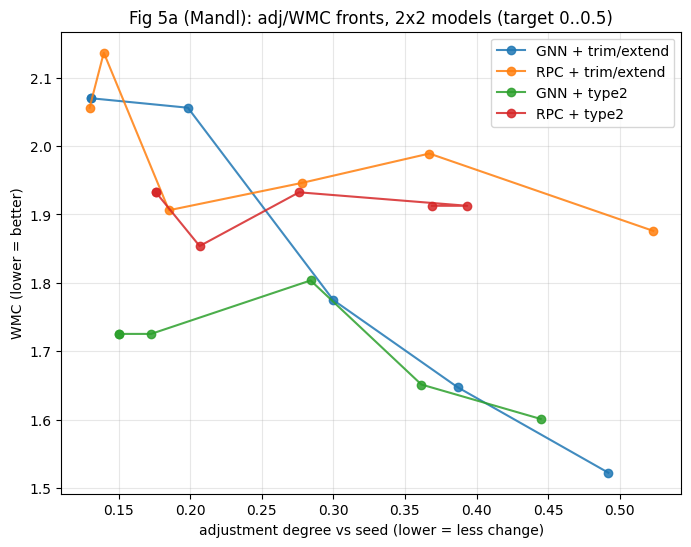

,model,alpha,adj_vs_seed,WMC,ATT,RTT,cost,redun%
0,GNN + trim/extend,0.00,0.5615,1.5225,15.7155,128.0,0.6465,0.0000
1,GNN + trim/extend,0.25,0.6512,1.6256,15.1741,130.0,0.6074,0.0000
2,GNN + trim/extend,0.50,0.4722,1.6514,14.0642,132.0,0.5464,0.0000
3,GNN + trim/extend,0.75,0.5444,1.4935,12.2903,156.0,0.4763,5.8824
4,GNN + trim/extend,1.00,0.6498,1.3341,10.4072,376.0,0.3154,41.6667
5,RPC + trim/extend,0.00,0.5361,1.8189,22.2685,138.0,0.6970,0.0000
6,RPC + trim/extend,0.25,0.5156,1.5730,16.7611,146.0,0.6800,0.0000
7,RPC + trim/extend,0.50,0.5008,1.4419,13.3924,166.0,0.6221,0.0000
8,RPC + trim/extend,0.75,0.5684,1.4978,12.0064,154.0,0.4673,5.8824
9,RPC + trim/extend,1.00,0.5985,1.3341,10.3051,334.0,0.3123,41.1765


[results] table (20 rows) -> D:\PythonProjects\connectpt\artifacts\results\final_fig5b_attrtt_Mandl_smoke.csv


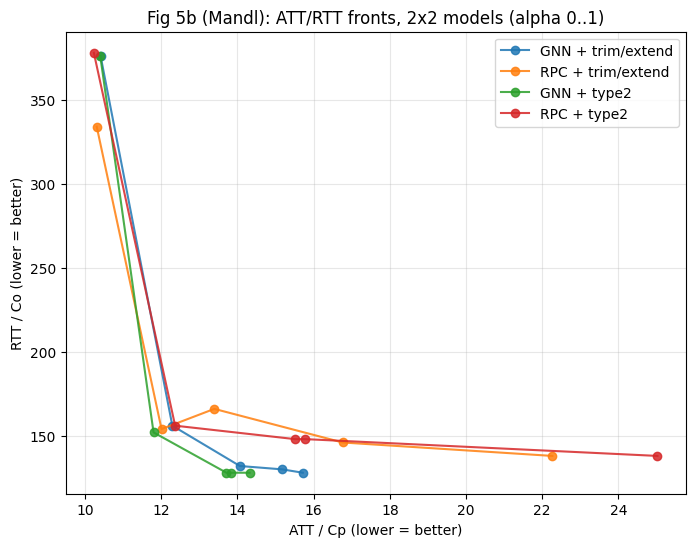

In [5]:
PARETO_CITY = CITIES[0]
pspec = next(s for s in BENCHMARK_SPECS if s["city"] == PARETO_CITY)
ptensors, pinit = load_benchmark_graph(pspec)
_ps = algo_settings(PARETO_CITY)
_pnb = int(_ps["bco_bees"])


def _run_abl(construct, edit, *, adj_target=None, alpha=None, tag=""):
    """One 2x2 run. alpha set -> ATT/RTT weights; adj_target set -> adj cap."""
    var = abl_variant(construct, edit, _pnb)
    if alpha is not None:
        weights = {"demand_time_weight": alpha, "route_time_weight": 1.0 - alpha,
                   "median_connectivity_weight": 0.0}
    else:
        weights = OUR_WEIGHTS
    cfg = build_bco_cfg(
        run_name=f"{PARETO_CITY}_{tag}_{var['run_name']}",
        n_routes=pspec["n_routes"], min_route_len=pspec["min_route_len"],
        max_route_len=pspec["max_route_len"], use_neural_bees=var["use_neural_bees"],
        n_bees=_pnb, n_type1_bees=var["n_type1_bees"], n_type2_bees=var["n_type2_bees"],
        n_type4_bees=0, n_type5_bees=var["n_type5_bees"], n_type6_bees=0, n_type7_bees=0,
        **_ps.get("bco_args", {}), **weights)
    bco_cfg_set(cfg, n_iterations=_ps["bco"])
    if adj_target is not None:
        bco_cfg_set(cfg, adjustment_degree_weight=float(ADJ_FIXED_W),
                    adjustment_degree_objective="cap",
                    adjustment_degree_target=float(adj_target),
                    adjustment_degree_gap=ADJ_GAP, adjustment_degree_mode=ADJ_MODE)
    res = run_bco(cfg, pinit, tensors=ptensors, run_name_scope=f"{PARETO_CITY}_")
    return res[3], res[1]


def _abl_row(model, sweep_name, sweep_val, routes, metrics):
    rt = as_route_tensor(routes)
    return {"model": model, sweep_name: float(sweep_val),
            "adj_vs_seed": adj_vs_init(rt, pinit), "WMC": conn_metric(metrics),
            "ATT": metric_value(metrics, "ATT"), "RTT": metric_value(metrics, "RTT"),
            "cost": metric_value(metrics, "cost"), "redun%": redundancy_pct(rt)}


def _plot_models(df, x, y, sweep, xlabel, ylabel, title, front=False):
    fig, ax = plt.subplots(figsize=(8, 6))
    for model in ABL_MODELS:
        sub = df[df["model"] == model].sort_values(sweep)
        if not sub.empty:
            ax.plot(sub[x], sub[y], marker="o", label=model, alpha=0.85)
    if front and not df.empty:
        f = df[nondominated_mask(df, x, y)].sort_values([x, y])
        if not f.empty:
            ax.plot(f[x], f[y], "k--", lw=1.8, label="combined Pareto front")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3)
    plt.show(); plt.close(fig)


# Fig 5a: adjustment-degree fronts -- 4 models swept over adj target (0..0.5)
adj_rows = []
for _model in ABL_MODELS:
    _c, _e = _model.split(" + ")
    for _t in ADJ_TARGET_GRID:
        try:
            _r, _m = _run_abl(_c, _e, adj_target=_t, tag=f"adj{_t}")
            adj_rows.append(_abl_row(_model, "adj_target", _t, _r, _m))
        except Exception as exc:
            print(f"{_model} adj_target={_t} FAILED: {exc}")
adj_df = pd.DataFrame(adj_rows)

# Fig 5b: ATT/RTT (Cp/Co) fronts -- 4 models swept over alpha (0..1)
_arows = []
for _model in ABL_MODELS:
    _c, _e = _model.split(" + ")
    for _a in ALPHA_GRID:
        try:
            _r, _m = _run_abl(_c, _e, alpha=_a, tag=f"a{_a}")
            _arows.append(_abl_row(_model, "alpha", _a, _r, _m))
        except Exception as exc:
            print(f"{_model} alpha={_a} FAILED: {exc}")
alpha_df = pd.DataFrame(_arows)

if not adj_df.empty:
    display(adj_df.round(4))
    save_table(adj_df.round(4), f"final_fig5a_adj_{PARETO_CITY}" + ("_smoke" if SMOKE else ""))
    _plot_models(adj_df, "adj_vs_seed", "WMC", "adj_target",
                 "adjustment degree vs seed (lower = less change)",
                 "WMC (lower = better)",
                 f"Fig 5a ({PARETO_CITY}): adj/WMC fronts, 2x2 models (target 0..0.5)")
if not alpha_df.empty:
    display(alpha_df.round(4))
    save_table(alpha_df.round(4), f"final_fig5b_attrtt_{PARETO_CITY}" + ("_smoke" if SMOKE else ""))
    _plot_models(alpha_df, "ATT", "RTT", "alpha",
                 "ATT / Cp (lower = better)", "RTT / Co (lower = better)",
                 f"Fig 5b ({PARETO_CITY}): ATT/RTT fronts, 2x2 models (alpha 0..1)")


## E3 - minimal intervention: our model under different adj targets

Re-runs **our model (GNN + trim/extend)** with the adjustment-degree cap set to several targets and shows seed -> edited route figures per target -- how much the network changes as the cap tightens. (Previously E3 used the no-adj main run; now it sweeps the target.)

[Mandl_e3_0.0_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=12 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=12 trim_only=0 trim_then_extend=0 (total=24)
[Mandl_e3_0.15_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=12 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=12 trim_only=0 trim_then_extend=0 (total=24)
[Mandl_e3_0.3_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=12 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=12 trim_only=0 trim_then_extend=0 (total=24)
[Mandl_e3_0.5_abl_GNN_trimextend] route_selection=uniform-random | bee split: heuristic_rebuild=12 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=12 trim_only=0 trim_then_extend=0 (total=24)


,target,redun%,adj_vs_seed,WMC,ATT,RTT
0,0.00,12.5000,0.1080,2.2046,22.8831,168.0
1,0.15,6.6667,0.1639,1.8831,22.2530,152.0
2,0.30,6.6667,0.3000,1.7749,16.0495,154.0
3,0.50,0.0000,0.4425,1.5225,15.8953,128.0


[results] table (4 rows) -> D:\PythonProjects\connectpt\artifacts\results\final_e3_targets_Mandl_smoke.csv


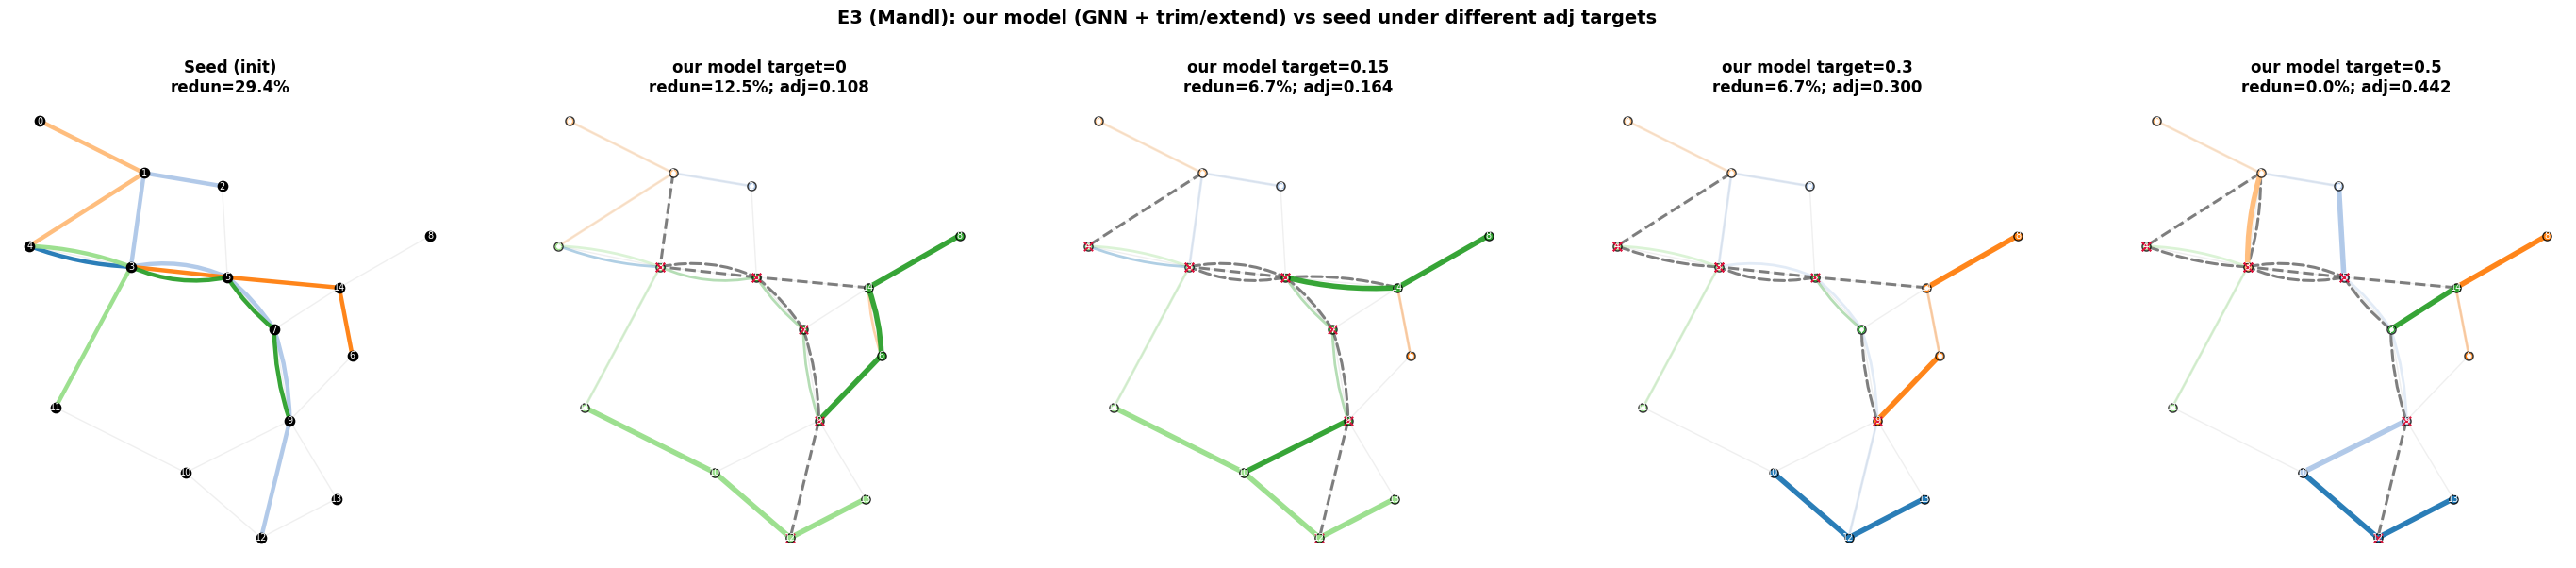

In [6]:
E3_CITY = CITIES[0]
e3_spec = next(s for s in BENCHMARK_SPECS if s["city"] == E3_CITY)
e3_tensors, e3_init = load_benchmark_graph(e3_spec)

# Our model = GNN + trim/extend, re-run under several adjustment-degree targets
# to show how the edited network deviates from the seed as the cap tightens.
e3_rows = []
e3_routes = {"Seed (init)": as_route_tensor(e3_init)}
for _t in E3_TARGETS:
    try:
        _r, _m = _run_abl("GNN", "trim/extend", adj_target=_t, tag=f"e3_{_t}")
        rt = as_route_tensor(_r)
        e3_routes[f"target={_t:g}"] = rt
        e3_rows.append({"target": _t, "redun%": redundancy_pct(rt),
                        "adj_vs_seed": adj_vs_init(rt, e3_init), "WMC": conn_metric(_m),
                        "ATT": metric_value(_m, "ATT"), "RTT": metric_value(_m, "RTT")})
    except Exception as exc:
        print(f"E3 target={_t} FAILED: {exc}")
e3_df = pd.DataFrame(e3_rows).round(4)
display(e3_df)
save_table(e3_df, f"final_e3_targets_{E3_CITY}" + ("_smoke" if SMOKE else ""))

labels = list(e3_routes)
fig, axes = plt.subplots(1, len(labels), figsize=(7 * len(labels), 7), squeeze=False)
_sr = as_route_tensor(e3_init); _sr = _sr[0] if _sr.ndim == 3 else _sr
for ax, lab in zip(axes[0], labels):
    rt = e3_routes[lab]; rr = rt[0] if rt.ndim == 3 else rt
    try:
        if lab.startswith("Seed"):
            route_plots.plot_plain_route_set(ax, rr, e3_tensors["node_locs"],
                e3_tensors["street_adj"], title=lab,
                subtitle=f"redun={redundancy_pct(rt):.1f}%")
        else:
            route_plots.plot_route_diff(ax, rr, _sr, e3_tensors["node_locs"],
                e3_tensors["street_adj"], title=f"our model {lab}",
                subtitle=f"redun={redundancy_pct(rt):.1f}%; adj={adj_vs_init(rt, e3_init):.3f}")
    except Exception as exc:
        ax.set_title(f"{lab}: plot failed ({exc})")
fig.suptitle(f"E3 ({E3_CITY}): our model (GNN + trim/extend) vs seed under different adj targets",
             fontsize=14, fontweight="bold")
plt.show(); plt.close(fig)


## E4 - Convergence (cost vs iteration)

Cost trajectories for the iterative methods (SA / GA / HH / BCO / neural BCO / Our model) on one city. **Early stopping is OFF** so every method runs its full budget.

[Mandl_conv_seeded_bco_heuristic_from_lc_mumford0] route_selection=uniform-random | bee split: heuristic_rebuild=12 local_endpoint_edit=12 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=24)
[Mandl_conv_seeded_neural_bco_from_lc_mumford0] route_selection=uniform-random | bee split: heuristic_rebuild=12 local_endpoint_edit=12 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=24)
[Mandl_conv_our_nbco_neural_rebuild_trim_extend] route_selection=uniform-random | bee split: heuristic_rebuild=12 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=12 trim_only=0 trim_then_extend=0 (total=24)


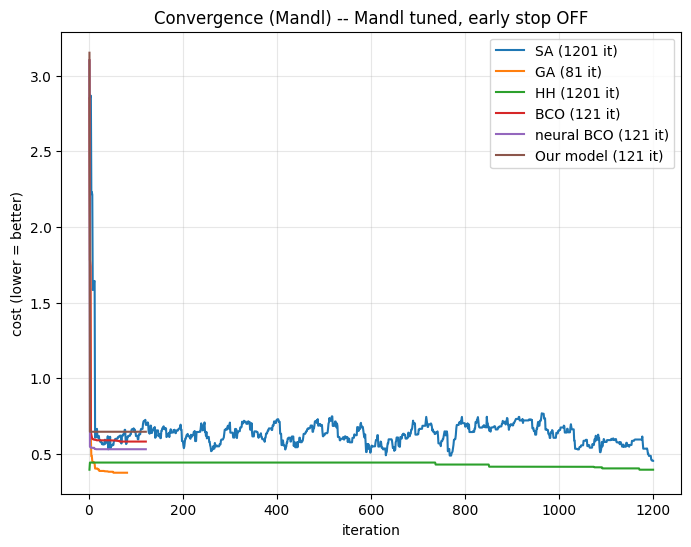

[results] table (1201 rows) -> D:\PythonProjects\connectpt\artifacts\results\final_convergence_Mandl_smoke.csv
convergence saved: ['SA', 'GA', 'HH', 'BCO', 'neural BCO', 'Our model'] | EARLY_STOP_PATIENCE=None
convergence settings: {'sa': 1200, 'hh': 1200, 'ga': 80, 'ga_pop': 40, 'nsgaii': (80, 40), 'bco': 120, 'bco_bees': 24, 'sa_args': {'initial_temp': 0.08, 'final_temp': 0.003, 'cooling_rate': 6.5e-05, 'reheating_threshold': 300, 'reheating_factor': 1.02}, 'bco_args': {'worse_accept_temperature': 0.02, 'worse_accept_decay': 0.985, 'worse_accept_min_temperature': 0.001, 'worse_selection_temperature': 0.02, 'worse_selection_decay': 0.985, 'worse_selection_uniform_mix': 0.1, 'worse_selection_elite_count': 2}}


In [7]:
CONV_CITY = CITIES[0]
cspec = next(s for s in BENCHMARK_SPECS if s["city"] == CONV_CITY)
ctensors, cinit = load_benchmark_graph(cspec)
nr, mn, mx = cspec["n_routes"], cspec["min_route_len"], cspec["max_route_len"]
conv = {}
conv_settings = algo_settings(CONV_CITY)


def _ravel_hist(h):
    if h is None:
        return []
    arr = np.asarray(h.detach().cpu() if hasattr(h, "detach") else h).ravel()
    return [float(v) for v in arr]


for name, run in [
    ("SA", lambda: run_sa(_sa_cfg(CONV_CITY, f"{CONV_CITY}_csa", nr, mn, mx),
            cinit, tensors=ctensors, run_name_scope=f"{CONV_CITY}_conv_",
            return_history=True)),
    ("GA", lambda: run_ga(_ga_cfg(CONV_CITY, f"{CONV_CITY}_cga", nr, mn, mx),
            cinit, tensors=ctensors, run_name_scope=f"{CONV_CITY}_conv_",
            return_history=True)),
    ("HH", lambda: run_hh(_hh_cfg(CONV_CITY, f"{CONV_CITY}_chh", nr, mn, mx),
            cinit, tensors=ctensors, run_name_scope=f"{CONV_CITY}_conv_",
            return_history=True)),
]:
    try:
        ch = run()[-1]
        conv[name] = _ravel_hist(ch[0] if ch else None)
    except Exception as exc:
        print(f"conv {name} FAILED: {exc}")

for name, vkey in [("BCO", "seeded_heuristic"), ("neural BCO", "seeded_neural")]:
    try:
        v = next(x for x in BCO_VARIANTS if x["key"] == vkey)
        cfg = _variant_bco_cfg(CONV_CITY, cspec, v, run_name_suffix="conv_")
        ch = {}
        run_bco(cfg, cinit, tensors=ctensors, run_name_scope=f"{CONV_CITY}_conv_", cost_history_out=ch)
        conv[name] = _ravel_hist(ch.get("history"))
    except Exception as exc:
        print(f"conv {name} FAILED: {exc}")

try:
    ch = {}
    run_bco(_our_model_cfg(CONV_CITY, cspec, run_name_suffix="conv_"),
            cinit, tensors=ctensors, run_name_scope=f"{CONV_CITY}_conv_",
            cost_history_out=ch)
    conv["Our model"] = _ravel_hist(ch.get("history"))
except Exception as exc:
    print(f"conv Our model FAILED: {exc}")

fig, ax = plt.subplots(figsize=(8, 6))
for name, h in conv.items():
    if h:
        ax.plot(range(1, len(h) + 1), h, label=f"{name} ({len(h)} it)")
ax.set_xlabel("iteration"); ax.set_ylabel("cost (lower = better)")
ax.set_title(f"Convergence ({CONV_CITY}) -- Mandl tuned, early stop OFF")
ax.legend(); ax.grid(alpha=0.3)
plt.show(); plt.close(fig)

conv_df = pd.DataFrame({k: pd.Series(v) for k, v in conv.items()})
save_table(conv_df, f"final_convergence_{CONV_CITY}" + ("_smoke" if SMOKE else ""))
print(f"convergence saved: {list(conv)} | EARLY_STOP_PATIENCE={EARLY_STOP_PATIENCE}")
print("convergence settings:", conv_settings)

## Next steps / TODO
- Swap `OUR_MODEL_PATH` to a route+conn+**adj**-trained model when ready.
- Flip `SMOKE=False` for the full Mumford0-3 run (3 seeds).
- E2: tune the trim/extend bee split if the front does not separate.

## E5 - Paper Fig 3 (Cp x Co Pareto) + Fig 5 (RL ablation)

Reproduces the paper's canonical figures via `run_alpha_pareto_sweep` + `plot_alpha_pareto_grid` (x = Cp = ATT passenger, y = Co = RTT operator), sweeping alpha 0->1.

- **Fig 3**: Cp x Co trade-off front per method.
- **Fig 5 (RL ablation)**: our **trained** standalone edit policy vs the same architecture **untrained** (`random_policy=True`) -- the analog of the paper's NEA vs RC-EA, isolating the value of training from the structure alone.

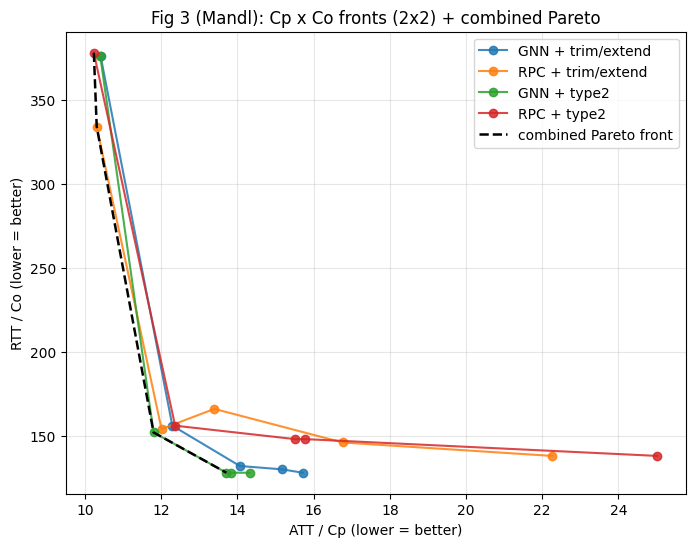

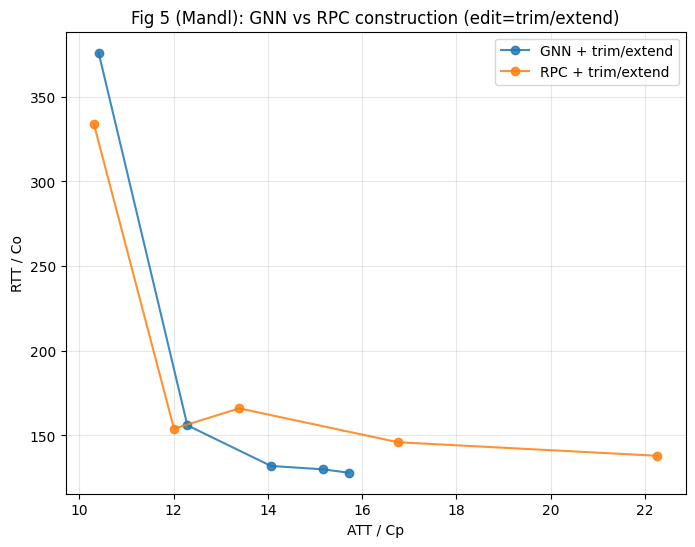

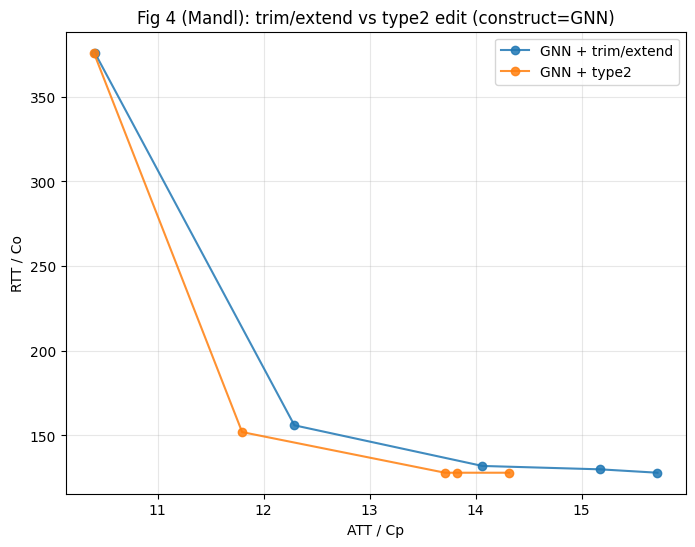

our model = 'GNN + trim/extend' (neural NBCO rebuild + our trim/extend edit bee)


In [8]:
# Reuses alpha_df from E2 (4 models x alpha grid).
if "alpha_df" not in globals() or alpha_df.empty:
    raise RuntimeError("Run the E2 cell first (it computes alpha_df).")

# Fig 3: all four 2x2 models on Cp x Co + one combined non-dominated Pareto front.
_plot_models(alpha_df, "ATT", "RTT", "alpha",
             "ATT / Cp (lower = better)", "RTT / Co (lower = better)",
             f"Fig 3 ({PARETO_CITY}): Cp x Co fronts (2x2) + combined Pareto",
             front=True)

# Fig 5: GNN vs RPC construction (edit fixed = trim/extend) -> GNN contribution.
_plot_models(alpha_df[alpha_df["model"].isin(["GNN + trim/extend", "RPC + trim/extend"])],
             "ATT", "RTT", "alpha", "ATT / Cp", "RTT / Co",
             f"Fig 5 ({PARETO_CITY}): GNN vs RPC construction (edit=trim/extend)")

# Fig 4: trim/extend vs type2 edit (construct fixed = GNN) -> our edit-bee contribution.
_plot_models(alpha_df[alpha_df["model"].isin(["GNN + trim/extend", "GNN + type2"])],
             "ATT", "RTT", "alpha", "ATT / Cp", "RTT / Co",
             f"Fig 4 ({PARETO_CITY}): trim/extend vs type2 edit (construct=GNN)")
print("our model = 'GNN + trim/extend' (neural NBCO rebuild + our trim/extend edit bee)")
